# Rent Price Prediction
I approached the rent prediction task with the standard steps of data cleaning, exploratory data analysis then model training and evaluation.  

## 1.1 Data loading and cleaning
I applied the following basic processing and sanitizing on the dataset.  
  - Drop duplicate listings by `scoutId`.
  - Parse dates and convert boolean-like columns.
  - Enforce numeric types for key columns (`livingSpace`, `totalRent`, `noRooms`, etc.).
  - **Filter extremes**: `livingSpace` 10–400 m², `totalRent` 100–10 000 €, `noRooms` 1–10.
  - Drop rows missing key fields (`totalRent`, `livingSpace`, `regio1`, `typeOfFlat`).

I also added some engineered features namely 
  - Hierarchical Location Encoding: To capture the location factor without over-parameterizing the model, I added the Spatial Mean-Encodings. By calculating average rent values across hierarchical granularities (geo_plz (ZIP), regio3 (City/District), and regio2 (State)), the model gains an interpretable benchmark of regional price levels.
  - Target Stabilization: Adopted log(totalRent) as the primary target variable. This logarithmic transformation normalizes the right-skewed price distribution and stabilizes variance across different price segments.

,value
regio1,Sachsen
serviceCharge,181.27
heatingType,floor_heating
telekomTvOffer,None
telekomHybridUploadSpeed,NaN
...,...
_parse_failed,None
rent_per_sqm,10.599971
avg_rent_per_sqm_plz,10.843896
avg_total_rent_regio3,6.471779


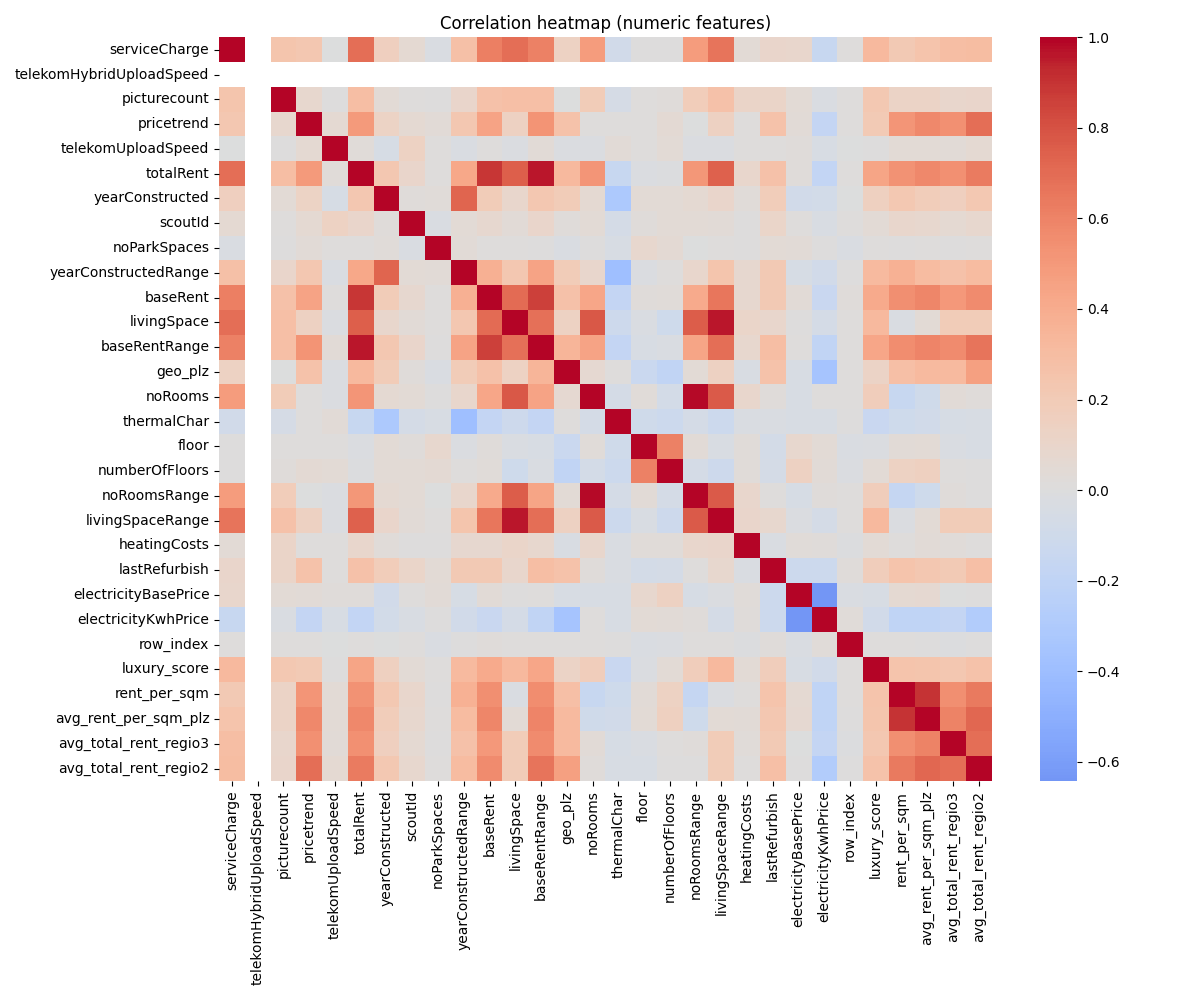

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
import os
os.chdir(PROJECT_ROOT)  # so data paths resolve correctly
import pandas as pd

from tools.data_pipeline import (
    PROCESSED_DATASET, RAW_PARQUET, RAW_CSV,
    build_dataset, run_basic_eda, REPORTS_DIR,
)

# Paths relative to project root
processed_path = PROJECT_ROOT / PROCESSED_DATASET
raw_parquet_path = PROJECT_ROOT / RAW_PARQUET
raw_csv_path = PROJECT_ROOT / RAW_CSV

# Load cleaned data: build from raw if needed, else require cleaned file to exist
if processed_path.exists():
    df = pd.read_parquet(processed_path)
elif raw_parquet_path.exists() or raw_csv_path.exists():
    build_dataset()
    df = pd.read_parquet(processed_path)
else:
    raise FileNotFoundError(
        f"Need either cleaned data at {processed_path} or raw data at {raw_parquet_path} or {raw_csv_path}. "
        "Place the file(s) there or run this notebook from the project root after building the dataset."
    )

# Visualize one row of cleaned data (first row, transposed so each column is readable)
one_row = df.iloc[0:1].T
one_row.columns = ["value"]
display(one_row)

# Run EDA and show the saved plots inline
run_basic_eda(df)
from IPython.display import Image, display
reports_dir = PROJECT_ROOT / REPORTS_DIR
edas = sorted(reports_dir.glob("run_*"), key=lambda p: p.stat().st_mtime, reverse=True)
if edas:
    for name in ["correlation_heatmap.png"]:
        path = edas[0] / name
        if path.exists():
            display(Image(filename=str(path)))

## 1.2 Model development with structural data

The first step for developing rent prediction model with the structural data was feature selection.  

### Numerical Features

I used a correlation heatmap as a filter to refine the set. I kept features that showed a clear relationship with log_totalRent. If a feature had almost zero correlation, I dropped it to simplify the model. I also kept an eye out for multicollinearity—for example, since livingSpace and noRooms are so closely related, I prioritized the one that gave the cleanest signal to avoid redundant information.

### Categorical and Boolean Features

For these, I used a more manual approach based on common sense and rental market relevance.

I picked features that are known to drive price, like whether an apartment has a balcony, a built-in kitchen, or an elevator. I specifically filtered out categories that were either mostly empty (too many missing values) or had too many "random" unique entries that would have caused the model to overfit. This helped keep the model robust and focused on the features that actually matter for valuation.

## 1.3 Model development with text data

For the second step, I integrated GenAI to tap into the unstructured data that standard models usually ignore. I used the Gemini API (gemini-2.5-flash-lite) to process the raw apartment descriptions and extract "hidden" features, like a Luxury Score or the specific Renovation Status. Since property agents often hide high-value details (like "brand new kitchen" or "premium flooring") in the text rather than the checkboxes, this step was meant to capture that extra nuance. Even though the structural data was already very strong, this LLM pipeline showed how we can turn messy text into clean, numeric features that a model can actually understand.

## 1.2 Feature sets: selected (original) vs text-derived (generative AI)

We use two feature sources and **compare their impact on performance**:

- **Selected features** (`SELECTED_FEATURE_COLS`): These are **already present in the given dataset**. They include property attributes (living space, rooms, floor, construction year, condition, heating, etc.), location-based averages (e.g. `avg_rent_per_sqm_plz`, `avg_total_rent_regio3`), and amenities (balcony, cellar, lift, etc.) — i.e. structured fields from the original listing data.

- **Text-derived features** (`TEXT_DERIVED_FEATURE_COLS`): These were **added newly using generative AI** by extracting information from listing descriptions (e.g. floor_heating, built_in_kitchen, luxury_score, green_view, quiet_neighborhood, near_public_transport). They come from the LLM-enriched merged dataset.

The goal is to **compare model performance** when using:
1. **Selected structural features only** — baseline with original data.
2. **Selected structural features + text-derived** — same model with the added AI-derived features.


### 1.2b Comparing performance: selected structural only vs selected structural + text-derived

I trained the **same model** (e.g. CatBoost) twice — once with **selected features only** (original data) and once with **selected + text-derived features** (with the new AI-extracted columns). Using the **same train/test split**, we compare test RMSE, MAE, and R² to see whether the generative-AI-derived features improve predictions.

In [ ]:
# --- Model comparison using same setup as scripts/train_feature_sets.py ---

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tools.data_pipeline import PROCESSED_DATASET, build_dataset
from tools.train_model import (
    SELECTED_FEATURE_COLS,
    TEXT_DERIVED_FEATURE_COLS,
    get_feature_target,
    build_preprocessing_and_model,
    get_estimator,
)

# Match script constants
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_ROWS = 10_000

# Ensure cleaned data exists, then load (same file as script)
if not PROCESSED_DATASET.exists():
    build_dataset()
df = pd.read_parquet(PROCESSED_DATASET)

# Same sampling as scripts/train_feature_sets.py
if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_STATE)

# Build feature matrices exactly like the script
X_selected, y = get_feature_target(
    df,
    target_col="totalRent",
    feature_cols=SELECTED_FEATURE_COLS,
)
X_with_text, _ = get_feature_target(
    df,
    target_col="totalRent",
    feature_cols=SELECTED_FEATURE_COLS + TEXT_DERIVED_FEATURE_COLS,
)

print(f"Selected features: {X_selected.shape[1]} columns")
print(f"Selected + text-derived: {X_with_text.shape[1]} columns")

# Same train/test split for both feature sets (reproducible)
X_sel_train, X_sel_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_text_train, X_text_test, y_train2, y_test2 = train_test_split(
    X_with_text, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
assert (y_train.values == y_train2.values).all() and (y_test.values == y_test2.values).all()

# Compare CatBoost and XGBoost on selected vs selected + text-derived features
results = []

for model_name in ["catboost", "xgboost"]:
    # IMPORTANT: use default models from get_estimator(model_name) like the script (no custom params)
    # Selected features only
    est_sel = get_estimator(model_name=model_name)
    pipe_sel = build_preprocessing_and_model(X_sel_train, estimator=est_sel)
    pipe_sel.fit(X_sel_train, y_train)
    pred_sel = pipe_sel.predict(X_sel_test)

    # Selected + text-derived features
    est_text = get_estimator(model_name=model_name)
    pipe_text = build_preprocessing_and_model(X_text_train, estimator=est_text)
    pipe_text.fit(X_text_train, y_train)
    pred_text = pipe_text.predict(X_text_test)

    for feature_set, n_feats, preds in [
        ("Selected only (original data)", X_selected.shape[1], pred_sel),
        ("Selected + text-derived (generative AI)", X_with_text.shape[1], pred_text),
        ]:
        # Log-space metrics (same target as training)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        # Euro-scale metrics (antilog of totalRent)
        y_test_eur = np.exp(y_test)
        preds_eur = np.exp(preds)
        rmse_eur = np.sqrt(mean_squared_error(y_test_eur, preds_eur))
        mae_eur = mean_absolute_error(y_test_eur, preds_eur)

        results.append({
            "model": model_name,
            "feature_set": feature_set,
            "n_features": n_feats,
            "test_rmse": round(rmse, 3),
            "test_mae": round(mae, 3),
            "test_r2": round(r2, 4),
            "test_rmse_eur": round(rmse_eur, 1),
            "test_mae_eur": round(mae_eur, 1),
        })

comparison = pd.DataFrame(results).sort_values(["model", "feature_set"]).reset_index(drop=True)
print("Performance comparison (same data, same split, same defaults as scripts/train_feature_sets.py):")
display(comparison)

Selected features: 30 columns
Selected + text-derived: 41 columns
Performance comparison (same data, same split, same defaults as scripts/train_feature_sets.py):


,model,feature_set,n_features,test_rmse,test_mae,test_r2,test_rmse_eur,test_mae_eur
0,catboost,Selected + text-derived (generative AI),41,0.105,0.079,0.9604,114.4,66.6
1,catboost,Selected only (original data),30,0.107,0.080,0.9590,117.4,67.7
2,xgboost,Selected + text-derived (generative AI),41,0.111,0.081,0.9563,128.7,69.7
3,xgboost,Selected only (original data),30,0.112,0.083,0.9552,130.7,72.0


## Summary

To evaluate the impact of Large Language Models on rental predictions, I compared two distinct approaches. The Structural Set (30 features) consists of traditional "hard" data: square footage, room counts, and engineered regional price averages. The GenAI-Enhanced Set (41 features) builds on this by adding qualitative metrics—such as a "Luxury Score" and "Renovation Status"—extracted directly from unstructured listing descriptions using the Gemini API.
General Observations

Across all tests, the models achieved exceptionally high accuracy, with R2 scores consistently exceeding 0.95. The most striking observation is that while the GenAI features did lead to the best overall model (CatBoost at 0.9604), the improvement over the structural baseline was incremental rather than transformative.

## Key Observations: 

### Very high baseline with structural data:
The high starting accuracy (95.9%) indicates that the structural data—specifically the hierarchical regional averages—already captures the vast majority of price variance. In real estate, location and size are such dominant predictors that they create an information ceiling. Once the model knows an apartment's ZIP code and square footage, there is very little unexplained price left for the LLM to solve.

### Refinement with the GenAI features: 
The GenAI features functioned as a refinement layer. While the R2 only moved slightly, the RMSE showed a more noticeable drop. This suggests that the LLM was particularly effective at explaining outliers—those listings where the price seemed high for the area, but the text revealed premium features like "designer fittings" or " view to greenery" that weren't in the standard checkboxes.

### Feature redundancy between structural and text derived features:
A key reason the jump wasn't larger is Information Overlap. Many luxury indicators identified by Gemini are naturally correlated with existing features; for example, a 200m² penthouse is already flagged as "high-end" by its size and floor level. The model is essentially receiving the same "quality signal" from two different sources, leading to diminishing returns in predictive power.


# Further improvements

The addition of Generative AI for feature extraction did not yield the massive improvement I initially expected. This is likely because the structural data is already quite comprehensive and captures the most critical price drivers very effectively.

The real opportunity for Generative AI in this project isn't just in the numbers, but in the user experience. The next logical step would be to wrap this prediction model into a RAG (Retrieval-Augmented Generation) system. This would allow the model to go beyond a simple price output and generate human-like, natural language responses to user queries about the rental market.